# TensorFlow Course 1 Week 1 - Complete Practice Notebook

## A New Programming Paradigm

This notebook covers all the concepts from Week 1 of the TensorFlow specialization, providing hands-on practice with neural networks and the machine learning paradigm.


## Setup and Imports

Import all necessary libraries for our neural network implementations


In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


In [4]:
print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")

TensorFlow version: 2.20.0
NumPy version: 2.2.6


In [5]:
# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

## Understanding the Traditional vs ML Paradigm

Visual representation of the paradigm shift

Traditional Programming:

```
Rules + Data → Answers
```

Machine Learning:

```
Answers + Data → Rules
```

---

## Pattern Recognition Exercise

pattern recognition with simple X,Y relationship


In [6]:
# Pattern recognition challenge: Y = 2X - 1
# Let's see if you can spot the pattern

x_values = [-1, 0, 1, 2, 3, 4]
y_values = [-3, -1, 1, 3, 5, 7]

print("X values:", x_values)
print("Y values:", y_values)
print("\nCan you spot the pattern? Y = ?")
print("Answer: Y = 2X - 1")

# Verify the pattern
for i in range(len(x_values)):
    calculated_y = 2 * x_values[i] - 1
    print(f"X={x_values[i]}, Y={y_values[i]}, Calculated Y={calculated_y}")

X values: [-1, 0, 1, 2, 3, 4]
Y values: [-3, -1, 1, 3, 5, 7]

Can you spot the pattern? Y = ?
Answer: Y = 2X - 1
X=-1, Y=-3, Calculated Y=-3
X=0, Y=-1, Calculated Y=-1
X=1, Y=1, Calculated Y=1
X=2, Y=3, Calculated Y=3
X=3, Y=5, Calculated Y=5
X=4, Y=7, Calculated Y=7


## First Neural Network – Basic Setup  

This is the simplest possible **neural network**: a model with only **one input** and **one neuron** in a single dense (fully connected) layer.  

- `tf.keras.Input(shape=(1,))` → The model takes a **single input feature** (e.g., one number per sample).  
- `tf.keras.layers.Dense(units=1)` → Defines a **dense layer with one neuron**, which produces a single output value.  
- This setup is equivalent to a **linear regression model**:  

 $${Y} = w \cdot X + b$$

- `model.summary()` → Prints the structure of the network, including parameters (`weights` and `bias`).  

This example shows the **foundation of neural networks** before moving on to deeper or more complex architectures.  

In [7]:
# define a neural network with a single neuron
model = tf.keras.Sequential([
    tf.keras.Input(shape=(1,)),
    tf.keras.layers.Dense(units=1)
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

## Compile the Model  

In this step, we configure the **learning process** by specifying two key components:  

1. **Optimizer** → Algorithm that updates weights to minimize the loss.  
   - Here we use **SGD (Stochastic Gradient Descent)**.  

2. **Loss Function** → Measures how well the model is performing.  
   - Here we use **Mean Squared Error (MSE)**, defined as:  

   $$
   L = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2
   $$  

   - Where:  
     - $y_i$ = true value  
     - $\hat{y}_i$ = predicted value  
     - $N$ = number of samples  

**Code Meaning:**  
- `optimizer='sgd'` → Updates weights step by step using gradient descent.  
- `loss='mean_squared_error'` → Computes squared difference between predicted and actual values.  

This step prepares the model for training.  


In [8]:
model.compile(
    optimizer='sgd',
    loss='mean_squared_error'
)

print("Model compiled successfully!")
print("Optimizer: SGD (Stochastic Gradient Descent)")
print("Loss Function: Mean Squared Error")

Model compiled successfully!
Optimizer: SGD (Stochastic Gradient Descent)
Loss Function: Mean Squared Error


## Prepare Training Data  

We now define the training dataset as simple NumPy arrays.  

- **Input data (`xs`)**:  
  $$
  X = [-1, 0, 1, 2, 3, 4]
  $$  

- **Target data (`ys`)**:  
  $$
  Y = [-3, -1, 1, 3, 5, 7]
  $$  

- The relationship between $X$ and $Y$ follows approximately:  
  $$
  y = 2x - 1
  $$  

- **Data details:**  
  - `dtype=float` → Ensures values are stored as floating-point numbers.  
  - `.shape` → Confirms that both `X` and `Y` are **1-dimensional arrays** of length 6.  

This dataset is small and simple, which makes it ideal for training our **first neural network model**.  


In [9]:
# Prepare the training data as numpy arrays
xs = np.array([-1.0, 0.0, 1.0, 2.0, 3.0, 4.0], dtype=float)
ys = np.array([-3.0, -1.0, 1.0, 3.0, 5.0, 7.0], dtype=float)

print("Training data prepared:")
print(f"X values: {xs}")
print(f"Y values: {ys}")
print(f"Data type: {xs.dtype}")
print(f"Shape of X: {xs.shape}")
print(f"Shape of Y: {ys.shape}")

Training data prepared:
X values: [-1.  0.  1.  2.  3.  4.]
Y values: [-3. -1.  1.  3.  5.  7.]
Data type: float64
Shape of X: (6,)
Shape of Y: (6,)


## Train the Neural Network  

Now we train the model so it can learn the underlying relationship:  

$$
y = 2x - 1
$$  

- **Training Process:**  
  - `model.fit(xs, ys, epochs=500)` → Runs 500 passes (epochs) over the training data.  
  - In each epoch, the model:  
    1. Makes predictions for $X$.  
    2. Compares predictions $\hat{y}$ with true values $y$.  
    3. Calculates the **loss** using Mean Squared Error:  
       $$
       L = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2
       $$  
    4. Updates weights using **Stochastic Gradient Descent (SGD)**.  

- **Output:**  
  - Displays the loss value for each epoch.  
  - We expect the loss to **decrease over time**, showing that the model is learning.  

This step allows the neural network to approximate the linear mapping between inputs and outputs.  


In [10]:
# Train the model
print("Starting training...")
history = model.fit(xs, ys, epochs=500, verbose=1)

print("\nTraining completed!")
print("Watch how the loss decreased over time.")

Starting training...
Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 61.1450
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 48.5412
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 38.6163
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 30.7991
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 24.6403
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 19.7864
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 15.9594
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 12.9405
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 10.5574
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 8.6748
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 7.1860
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 6.0074
Epoch 13/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 5.0728
Epoch 14/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 4.3304
Epoch 15/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - l

## Visualize Training Progress  

After training, it’s useful to **plot the loss curve** to see how well the model learned.  

- **Code Explanation:**  
  - `plt.plot(history.history['loss'])` → Plots the loss value for each epoch.  
  - X-axis = **Epoch number** (training iterations).  
  - Y-axis = **Loss (Mean Squared Error)**.  
  - `plt.grid(True)` → Adds grid lines for better readability.  

- **Interpretation:**  
  - A **decreasing curve** means the model is improving its predictions over time.  
  - Ideally, the curve should flatten out as the model converges.  

- **Final loss value:**  
  - Reported with  
    $$
    L = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2
    $$  
  - The last value printed is the model’s loss after the final epoch.  

This visualization confirms whether training was successful and if the model properly fit the data.  


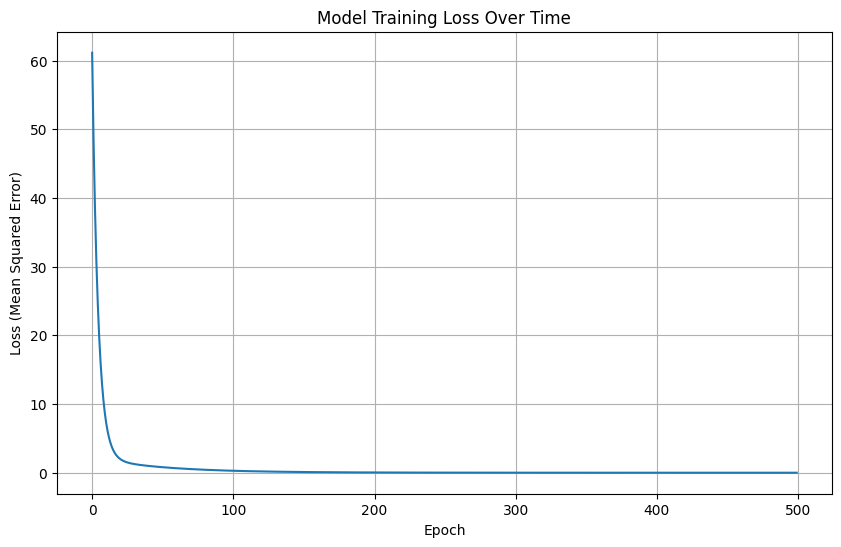

Final loss: 0.000072


In [11]:
# Plot training loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'])
plt.title('Model Training Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Loss (Mean Squared Error)')
plt.grid(True)
plt.show()

print(f"Final loss: {history.history['loss'][-1]:.6f}")

## Test the Model with Predictions  

Once the model is trained, we can test it on **unseen input values** to check how well it learned the mapping:  

$$
y = 2x - 1
$$  

- **Single Prediction:**  
  - Input: $X = 10$  
  - Model predicts $\hat{y}$ using learned weights and bias.  
  - Compare with the expected true value:  
    $$
    y = 2 \cdot 10 - 1 = 19
    $$  
  - The difference shows how close the model’s prediction is to the ground truth.  

- **Multiple Predictions:**  
  - Test values: $[5, 7, 8, 15]$  
  - For each $x$, compute:  
    - Predicted value $\hat{y}$ (from the model).  
    - Expected value $y = 2x - 1$.  
    - Difference $|\hat{y} - y|$.  

- **Interpretation:**  
  - If the model trained well, predictions should be **very close** to expected values.  
  - Small differences are normal due to optimization and approximation.  

This step validates the model’s ability to generalize beyond the training data.  


In [15]:
# Test the model with a new value
test_value = 10.0
prediction = model.predict(np.array([test_value]))  # Convert to numpy array

print(f"Input: X = {test_value}")
print(f"Predicted Y = {prediction[0][0]:.4f}")
print(f"Expected Y (using Y = 2X - 1) = {2 * test_value - 1}")
print(f"Difference: {abs(prediction[0][0] - (2 * test_value - 1)):.4f}")

# Test with multiple values
test_values = [5.0, 7.0, 8.0, 15.0]
print("\nMultiple predictions:")
for x in test_values:
    pred = model.predict(np.array([x]), verbose=0)  # Convert to numpy array
    expected = 2 * x - 1
    print(f"X={x}: Predicted={pred[0][0]:.2f}, Expected={expected}, Diff={abs(pred[0][0] - expected):.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Input: X = 10.0
Predicted Y = 18.9753
Expected Y (using Y = 2X - 1) = 19.0
Difference: 0.0247

Multiple predictions:
X=5.0: Predicted=8.99, Expected=9.0, Diff=0.01
X=7.0: Predicted=12.99, Expected=13.0, Diff=0.01
X=8.0: Predicted=14.98, Expected=15.0, Diff=0.02
X=15.0: Predicted=28.96, Expected=29.0, Diff=0.04


## Understand Model Parameters  

Finally, we inspect the **parameters (weights and bias)** that the neural network learned.  

- **Dense Layer Parameters:**  
  - `weights` → The slope of the line.  
  - `bias` → The intercept of the line.  

- **Learned Equation:**  
  After training, the model has essentially learned a linear function of the form:  

  $$
  \hat{y} = w \cdot x + b
  $$  

  - Where:  
    - $w$ = learned weight (expected ≈ 2)  
    - $b$ = learned bias (expected ≈ -1)  

- **Comparison:**  
  - **Target equation:**  
    $$
    y = 2x - 1
    $$  
  - **Learned equation:**  
    Close to the target, with small differences due to training and optimization.  

- **Interpretation:**  
  - If $w$ is very close to 2 and $b$ is very close to -1, the model successfully learned the true underlying relationship.  

This step confirms that the neural network not only produced correct predictions, but also discovered the actual parameters of the target function.  


In [16]:
# Get the learned weights and bias
layer = model.layers[0]  # Get the Dense layer
weights, bias = layer.get_weights()

print("Neural Network learned parameters:")
print(f"Weight (should be close to 2): {weights[0][0]:.4f}")
print(f"Bias (should be close to -1): {bias[0]:.4f}")

print(f"\nLearned equation: Y = {weights[0][0]:.4f} * X + {bias[0]:.4f}")
print("Target equation: Y = 2.0 * X - 1.0")

Neural Network learned parameters:
Weight (should be close to 2): 1.9964
Bias (should be close to -1): -0.9889

Learned equation: Y = 1.9964 * X + -0.9889
Target equation: Y = 2.0 * X - 1.0


## House Price Prediction Exercise  

In this exercise, we create a simple dataset for predicting **house prices** based on the number of bedrooms.  

- **Pricing Rule (given):**  
  - A **1-bedroom house** costs **$100k**.  
  - Each additional bedroom adds **$50k**.  

- **Training Data:**  
  - Inputs ($X$): Number of bedrooms  
    $$
    [1, 2, 3, 4, 5, 6]
    $$  
  - Outputs ($Y$): Price in hundreds of thousands of dollars  
    $$
    [1.0, 1.5, 2.0, 2.5, 3.0, 3.5]
    $$  

- **True Relationship:**  
  $$
  \text{Price (in 100k)} = 0.5 \cdot \text{Bedrooms} + 0.5
  $$  

- **Example:**  
  - 1 bedroom → $1.0 \, (100k)$  
  - 2 bedrooms → $1.5 \, (150k)$  
  - 6 bedrooms → $3.5 \, (350k)$  

This dataset will later be used to train a neural network model to learn the pricing function.  


In [17]:
def create_training_data():
    """Creates training data for house price prediction.
    1-bedroom house costs 100k, each additional bedroom adds 50k.
    """
    n_bedrooms = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0], dtype=float)
    price_in_hundreds_of_thousands = np.array([1.0, 1.5, 2.0, 2.5, 3.0, 3.5], dtype=float)

    return n_bedrooms, price_in_hundreds_of_thousands

# Create the data
bedrooms, prices = create_training_data()

print("House Price Training Data:")
for i in range(len(bedrooms)):
    print(f"{bedrooms[i]:.0f} bedroom(s): ${prices[i]*100:.0f}k")


House Price Training Data:
1 bedroom(s): $100k
2 bedroom(s): $150k
3 bedroom(s): $200k
4 bedroom(s): $250k
5 bedroom(s): $300k
6 bedroom(s): $350k


## Build House Price Prediction Model  

We now build and train a simple neural network to learn the **house price prediction rule**:  

$$
\text{Price (in 100k)} = 0.5 \cdot \text{Bedrooms} + 0.5
$$  

- **Model Architecture:**  
  - Input layer: accepts a single feature (**number of bedrooms**).  
  - Dense layer: one neuron that outputs the predicted house price.  

- **Compilation:**  
  - Optimizer: **SGD (Stochastic Gradient Descent)** → adjusts weights to minimize error.  
  - Loss function: **Mean Squared Error (MSE)** → measures the squared difference between predicted and actual prices.  

- **Training:**  
  - `epochs=1000` → model trains for 1000 iterations over the dataset.  
  - Each epoch updates weights to reduce the loss.  
  - Final printed loss shows how close the model’s predictions are to the target function.  

This step teaches the neural network the linear relationship between **bedrooms** and **house prices**.  


In [18]:
# create a model for house price prediction
house_model = tf.keras.Sequential([
    tf.keras.Input(shape=(1,)),
    tf.keras.layers.Dense(units=1)
])

# compile the model
house_model.compile(optimizer = 'sgd', loss='mean_squared_error')

# Train the model
print("Training house price prediction model...")
house_history = house_model.fit(bedrooms, prices, epochs=1000, verbose=0)

print(f"Final loss: {house_history.history['loss'][-1]:.6f}")



Training house price prediction model...
Final loss: 0.000011


## Test House Price Predictions  

Now we test the trained model on **new bedroom counts**, including values not in the training set.  

- **Test Inputs:**  
  $$
  [7.0, \; 10.0, \; 2.5]
  $$  

- **Expected Price Formula:**  
  $$
  \text{Price (in 100k)} = 0.5 + 0.5 \cdot \text{Bedrooms}
  $$  

- **Examples:**  
  - $7.0$ bedrooms → Expected $= 0.5 + (0.5 \times 7) = 4.0 \; (400k)$  
  - $10.0$ bedrooms → Expected $= 0.5 + (0.5 \times 10) = 5.5 \; (550k)$  
  - $2.5$ bedrooms → Expected $= 0.5 + (0.5 \times 2.5) = 1.75 \; (175k)$  

- **Model Output:**  
  - For each test input, the model predicts a price $\hat{y}$.  
  - Compare prediction with the expected price.  
  - Report the difference:  
    $$
    \text{Diff} = |\hat{y} - y|
    $$  

- **Interpretation:**  
  - A small difference means the model generalized well.  
  - This demonstrates the network’s ability to **interpolate** (e.g., 2.5 bedrooms) and **extrapolate** (e.g., 10 bedrooms).  

This confirms whether the trained model can make accurate predictions beyond the training data.  


In [21]:
# Test house price predictions
test_bedrooms = np.array([7.0, 10.0, 2.5], dtype='float')  # Including a half-bedroom scenario

print("House Price Predictions:")
for rooms in test_bedrooms:
    predicted_price = house_model.predict(np.array([rooms]), verbose=0)[0][0]  # Convert to numpy array
    expected_price = 0.5 + (0.5 * rooms)  # Mathematical formula: Price = 50k + 50k*bedrooms

    print(f"{rooms} bedroom(s):")
    print(f"  Predicted: ${predicted_price*100:.1f}k")
    print(f"  Expected: ${expected_price*100:.1f}k")
    print(f"  Difference: ${abs(predicted_price - expected_price)*100:.1f}k")
    print()

House Price Predictions:
7.0 bedroom(s):
  Predicted: $400.5k
  Expected: $400.0k
  Difference: $0.5k

10.0 bedroom(s):
  Predicted: $551.0k
  Expected: $550.0k
  Difference: $1.0k

2.5 bedroom(s):
  Predicted: $174.7k
  Expected: $175.0k
  Difference: $0.3k



## Compare Models Side by Side  

Now we compare the **two trained models** by inspecting their learned parameters (weights and biases).  

- **Model 1: $Y = 2X - 1$**  
  - Target equation:  
    $$
    y = 2x - 1
    $$  
  - Learned parameters:  
    - Weight $w \approx 2.0$  
    - Bias $b \approx -1.0$  

- **Model 2: House Price Prediction**  
  - Target equation (in 100k):  
    $$
    \text{Price} = 0.5 \cdot \text{Bedrooms} + 0.5
    $$  
  - Learned parameters:  
    - Weight $w \approx 0.5$  
    - Bias $b \approx 0.5$  

- **Printed Equations:**  
  - Model 1:  
    $$
    \hat{y} = w_1 \cdot x + b_1
    $$  
  - Model 2:  
    $$
    \hat{y} = w_2 \cdot \text{Bedrooms} + b_2
    $$  

- **Interpretation:**  
  - Both models successfully learned their respective linear relationships.  
  - Minor differences between learned and target parameters are expected due to optimization.  

This side-by-side comparison helps verify that the networks captured the intended functions.  


In [23]:
# Compare both models
print("=== MODEL COMPARISON ===")
print("\n1. Y = 2X - 1 Model:")
layer1 = model.layers[0]
w1, b1 = layer1.get_weights()
print(f"   Weight: {w1[0][0]:.4f} (target: 2.0)")
print(f"   Bias: {b1[0]:.4f} (target: -1.0)")

print("\n2. House Price Model:")
layer2 = house_model.layers[0]
w2, b2 = layer2.get_weights()
print(f"   Weight: {w2[0][0]:.4f} (target: 0.5)")
print(f"   Bias: {b2[0]:.4f} (target: 0.5)")

print("\n=== EQUATIONS ===")
print(f"Model 1: Y = {w1[0][0]:.3f}X + {b1[0]:.3f}")
print(f"Model 2: Price = {w2[0][0]:.3f}*Bedrooms + {b2[0]:.3f}")

=== MODEL COMPARISON ===

1. Y = 2X - 1 Model:
   Weight: 1.9964 (target: 2.0)
   Bias: -0.9889 (target: -1.0)

2. House Price Model:
   Weight: 0.5018 (target: 0.5)
   Bias: 0.4924 (target: 0.5)

=== EQUATIONS ===
Model 1: Y = 1.996X + -0.989
Model 2: Price = 0.502*Bedrooms + 0.492
